# Analiza zamud avtobusov

Cilj: zgraditi model za napovedovanje zamude avtobusa glede na linijo, postajo, čas in vreme.

**Pipeline:**
1. Nalaganje silver podatkov iz Supabase
2. Analiza porazdelitve zamud
3. Čiščenje outlierjev
4. Eksplorativna analiza
5. Pridobitev smeri iz Marprom API-ja
6. Inženiring značilk
7. Primerjava modelov + tuning
8. Izvoz v ONNX

## 1. Nalaganje podatkov

In [23]:
import os
import json
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from supabase import create_client
from dotenv import load_dotenv
from datetime import date, timedelta
import io

load_dotenv()

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_SERVICE_KEY")
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

data = supabase.storage.from_("silver").download("buses/latest.parquet")
df = pd.read_parquet(io.BytesIO(data))

print(f"Vrstic: {len(df)}")
print(f"Stolpci: {df.columns.tolist()}")
df.head()

Vrstic: 1212694
Stolpci: ['route_id', 'stop_sequence', 'delay_seconds', 'bearing', 'current_stop_id', 'recorded_at', 'recorded_at_local', 'temperature', 'wind_speed', 'rain']


,route_id,stop_sequence,delay_seconds,bearing,current_stop_id,recorded_at,recorded_at_local,temperature,wind_speed,rain
0,84,31,71,80.0,243,2026-05-14 14:16:59.578073+00:00,2026-05-14 16:16:59.578073+02:00,11.8,2.06,0.0
1,81,30,2,243.0,423,2026-05-14 14:16:59.578073+00:00,2026-05-14 16:16:59.578073+02:00,11.8,2.06,0.0
2,81,31,2,243.0,423,2026-05-14 14:16:59.578073+00:00,2026-05-14 16:16:59.578073+02:00,11.8,2.06,0.0
3,81,32,2,243.0,423,2026-05-14 14:16:59.578073+00:00,2026-05-14 16:16:59.578073+02:00,11.8,2.06,0.0
4,81,33,2,243.0,423,2026-05-14 14:16:59.578073+00:00,2026-05-14 16:16:59.578073+02:00,11.8,2.06,0.0


## 2. Pregled podatkov

In [24]:
print(df.dtypes)
print("\n")
print(df.describe())

route_id                                       object
stop_sequence                                   int64
delay_seconds                                   int64
bearing                                       float64
current_stop_id                                object
recorded_at                       datetime64[ns, UTC]
recorded_at_local    datetime64[ns, Europe/Ljubljana]
temperature                                   float64
wind_speed                                    float64
rain                                          float64
dtype: object


       stop_sequence  delay_seconds       bearing   temperature    wind_speed  \
count   1.212694e+06   1.212694e+06  1.212694e+06  1.212694e+06  1.212694e+06   
mean    2.126058e+01   1.281378e+02  1.561564e+02  1.880610e+01  2.496187e+00   
std     1.206491e+01   3.506699e+02  1.022019e+02  4.975142e+00  1.478482e+00   
min     0.000000e+00  -1.020200e+04  0.000000e+00  7.140000e+00  0.000000e+00   
25%     1.200000e+01   0.000000e+00  7.

In [25]:
print("Manjkajoče vrednosti:")
print(df.isnull().sum())
print(f"\nŠtevilo linij: {df['route_id'].nunique()}")
print(f"Razpon stop_sequence: {df['stop_sequence'].min()} - {df['stop_sequence'].max()}")
print(f"\nStatistika zamud:")
print(f"  Povprečje: {df['delay_seconds'].mean():.1f}s")
print(f"  Mediana:   {df['delay_seconds'].median():.1f}s")
print(f"  Min:       {df['delay_seconds'].min()}s")
print(f"  Max:       {df['delay_seconds'].max()}s")

Manjkajoče vrednosti:
route_id             0
stop_sequence        0
delay_seconds        0
bearing              0
current_stop_id      0
recorded_at          0
recorded_at_local    0
temperature          0
wind_speed           0
rain                 0
dtype: int64

Število linij: 19
Razpon stop_sequence: 0 - 47

Statistika zamud:
  Povprečje: 128.1s
  Mediana:   35.0s
  Min:       -10202s
  Max:       13524s


## 3. Porazdelitev zamud

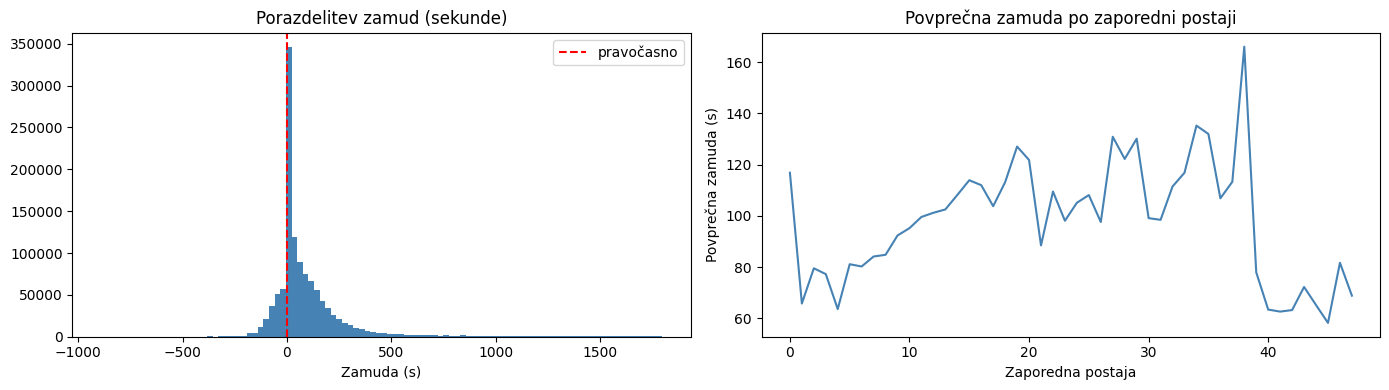

In [26]:
# začasni clean samo za vizualizacijo
df_viz = df[(df['delay_seconds'] >= -900) & (df['delay_seconds'] <= 1800)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_viz['delay_seconds'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Porazdelitev zamud (sekunde)')
axes[0].set_xlabel('Zamuda (s)')
axes[0].axvline(0, color='red', linestyle='--', label='pravočasno')
axes[0].legend()

df_viz.groupby('stop_sequence')['delay_seconds'].mean().plot(ax=axes[1], color='steelblue')
axes[1].set_title('Povprečna zamuda po zaporedni postaji')
axes[1].set_xlabel('Zaporedna postaja')
axes[1].set_ylabel('Povprečna zamuda (s)')

plt.tight_layout()
plt.show()

## 4. Analiza outlierjev

Zamude manjše od -10000s so očitno napake v podatkih. Kje so naravne meje?

In [27]:
# analiza prezgodnjih prihodov
early = df[df['delay_seconds'] < 0]
print(f"Prezgodnji avtobusi: {len(early)} ({len(early)/len(df)*100:.1f}%)")
print("\nPercentili prezgodnjih zamud:")
print(early['delay_seconds'].describe(percentiles=[.25, .5, .75, .9, .95, .99, .999]))

print("\nŠtevilo vrstic glede na mejo:")
for t in [-300, -600, -900, -1800]:
    count = len(df[df['delay_seconds'] < t])
    print(f"  Prej kot {abs(t)}s ({abs(t)//60} min): {count} vrstic ({count/len(df)*100:.2f}%)")

Prezgodnji avtobusi: 201013 (16.6%)

Percentili prezgodnjih zamud:
count    201013.000000
mean        -69.785253
std         167.470125
min      -10202.000000
25%         -83.000000
50%         -49.000000
75%         -24.000000
90%         -11.000000
95%          -6.000000
99%          -2.000000
99.9%        -1.000000
max          -1.000000
Name: delay_seconds, dtype: float64

Število vrstic glede na mejo:
  Prej kot 300s (5 min): 2381 vrstic (0.20%)
  Prej kot 600s (10 min): 858 vrstic (0.07%)
  Prej kot 900s (15 min): 585 vrstic (0.05%)
  Prej kot 1800s (30 min): 400 vrstic (0.03%)


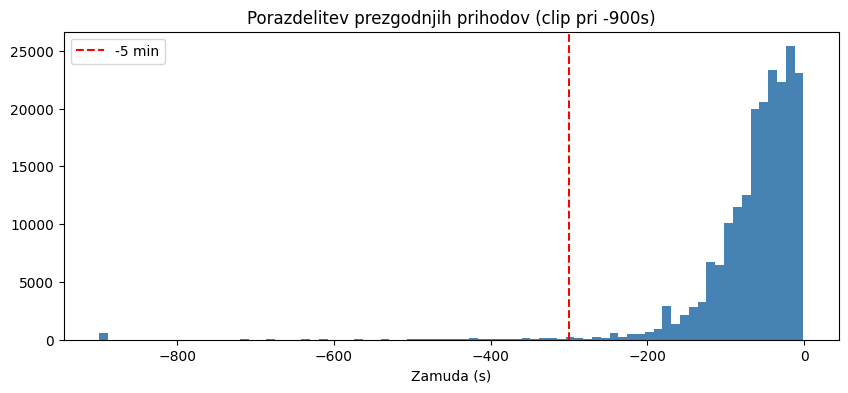

In [28]:
# histogram prezgodnjih prihodov — vidimo naravno mejo pri ~-300s
plt.figure(figsize=(10, 4))
plt.hist(df[df['delay_seconds'] < 0]['delay_seconds'].clip(lower=-900), bins=80, color='steelblue')
plt.axvline(-300, color='red', linestyle='--', label='-5 min')
plt.title('Porazdelitev prezgodnjih prihodov (clip pri -900s)')
plt.xlabel('Zamuda (s)')
plt.legend()
plt.show()

In [29]:
# analiza zamud na pozni strani
print("Število vrstic z veliko zamudo:")
for t in [600, 900, 1800, 3600]:
    count = len(df[df['delay_seconds'] > t])
    print(f"  Več kot {t}s ({t//60} min): {count} vrstic ({count/len(df)*100:.2f}%)")

Število vrstic z veliko zamudo:
  Več kot 600s (10 min): 56649 vrstic (4.67%)
  Več kot 900s (15 min): 39152 vrstic (3.23%)
  Več kot 1800s (30 min): 13783 vrstic (1.14%)
  Več kot 3600s (60 min): 575 vrstic (0.05%)


In [30]:
# odločitev: odstranimo zamude < -900s (15 min prezgodaj) in > 3600s (60 min zamude)
# skupaj odstranimo ~0.1% podatkov
df_clean = df[
    (df['delay_seconds'] >= -900) & 
    (df['delay_seconds'] <= 3600)
].copy()

print(f"Čiste vrstice: {len(df_clean)} ({len(df_clean)/len(df)*100:.1f}% originalnih)")

Čiste vrstice: 1211534 (99.9% originalnih)


## 5. Eksplorativna analiza

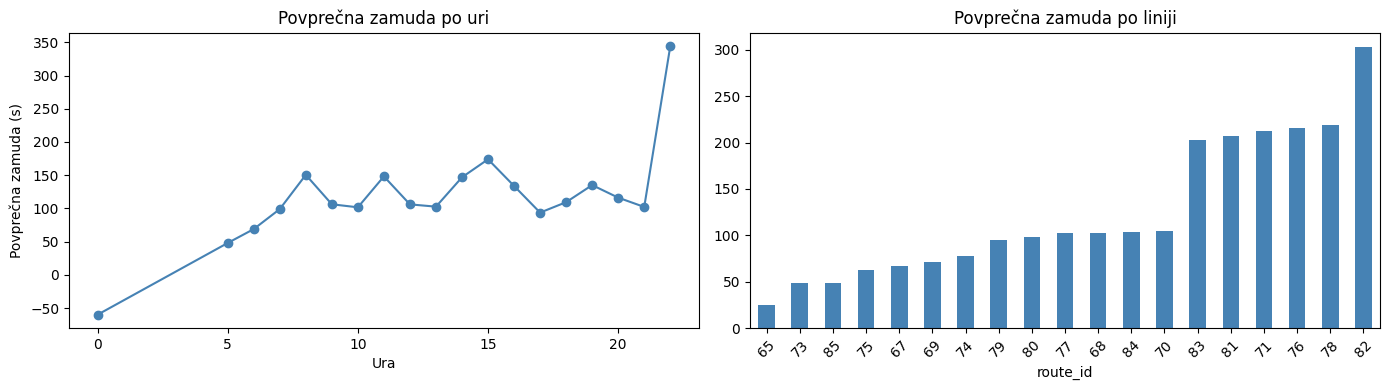

In [31]:
df_clean['hour'] = df_clean['recorded_at_local'].dt.hour
df_clean['day_of_week'] = df_clean['recorded_at_local'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_clean.groupby('hour')['delay_seconds'].mean().plot(ax=axes[0], color='steelblue', marker='o')
axes[0].set_title('Povprečna zamuda po uri')
axes[0].set_xlabel('Ura')
axes[0].set_ylabel('Povprečna zamuda (s)')

df_clean.groupby('route_id')['delay_seconds'].mean().sort_values().plot(
    kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Povprečna zamuda po liniji')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [32]:
# preverimo število meritev po uri — spike ob 22h je posledica specifičnih linij, ne časa
hour_counts = df_clean.groupby('hour').agg(
    count=('delay_seconds', 'count'),
    avg_delay=('delay_seconds', 'mean')
).reset_index()

print(hour_counts.to_string())

# preverimo katere linije vozijo ob 22h in zakaj je zamuda tako visoka
print("\nLinije ob 22h:")
print(df_clean[df_clean['hour'] == 22].groupby('route_id').agg(
    count=('delay_seconds', 'count'),
    avg_delay=('delay_seconds', 'mean')
).sort_values('avg_delay', ascending=False))

    hour  count   avg_delay
0      0      1  -60.000000
1      5  39040   47.940241
2      6  55577   68.873059
3      7  55991   98.973264
4      8  56618  150.523367
5      9  47547  106.219404
6     10  51073  101.659272
7     11  67973  148.184205
8     12  69564  106.086597
9     13  68921  102.641764
10    14  67525  146.844828
11    15  60440  173.932760
12    16  68210  133.801349
13    17  69490   93.694719
14    18  96828  109.389960
15    19  96533  135.110646
16    20  90160  116.210570
17    21  89937  102.214606
18    22  60106  344.089991

Linije ob 22h:
          count   avg_delay
route_id                   
81         8193  972.706091
80         1963  683.154356
69         6805  672.158560
82         5223  647.392112
65          172  175.116279
71         6257  165.235736
78        14675  128.367155
75         2165   69.165358
68          874   67.256293
70         3018   65.355533
84         3472   22.748848
77         1537   18.336370
74          262   16.217557
85  

## 6. Imena linij in analiza smeri

Povežemo route_id z imeni linij iz Marprom API-ja.

In [33]:
# nekatere linije ne vozijo ob nedeljah — vzamemo jutri (ponedeljek)
tomorrow = (date.today() + timedelta(days=1)).strftime("%Y-%m-%d")

resp = requests.get(f"https://marprom-proxy.derp.si/OBA/GetLines?Date={tomorrow}")
lines_data = resp.json()

route_map = {str(line['LineId']): f"{line['Code']} - {line['Description']}" 
             for line in lines_data['Lines']}

print(f"{'ID':5} {'Linija':35} {'Povp. zamuda':>15}")
print("-" * 60)
for r in sorted(df_clean['route_id'].unique()):
    avg = df_clean[df_clean['route_id'] == r]['delay_seconds'].mean()
    name = route_map.get(str(r), 'unknown')
    print(f"{r:5} {name:35} {avg:>12.0f}s")

ID    Linija                                 Povp. zamuda
------------------------------------------------------------
65    G5 - Rotovž                                   25s
67    G1 - Tezno                                    67s
68    G2 - Nova vas                                103s
69    G3 - Mestna krožna linija                     71s
70    G4 - Studenci - Limbuš                       104s
71    G6 - Vzpenjača                               212s
73    P7 - Kamnica                                  48s
74    P8 - Limbuš-Pekre                             78s
75    P9 - Zrkovci                                  62s
76    P10 - Malečnik                               215s
77    P11 - Razvanje                               103s
78    P12 - Dobrava-Supernova                      219s
79    P13 - Stražun–PC Tezno                        95s
80    P14 - Ledina                                  98s
81    P15 - Bresternica                            207s
82    P16 - Brezje                       

In [34]:
# preverimo ali smer vpliva na zamudo — bearing kot grob proxy
df_clean['heading'] = df_clean['bearing'].apply(
    lambda b: 'prva_polovica' if b < 180 else 'druga_polovica' if pd.notna(b) else None)

print("Povprečna zamuda glede na smer (bearing proxy):")
print(df_clean.groupby(['route_id', 'heading'])['delay_seconds'].mean().unstack())
print("\nZaključek: smer značilno vpliva na zamudo (npr. linija 71, 76, 83)")

Povprečna zamuda glede na smer (bearing proxy):
heading   druga_polovica  prva_polovica
route_id                               
65             23.524011      26.837949
67             50.995345      83.877828
68            107.097741      99.661114
69             63.474187      77.400998
70             92.414560     114.955908
71            116.068219     304.531225
73             43.735875      53.554147
74             95.810014      60.329106
75             70.456337      54.292262
76            148.998351     248.982579
77            106.462517      98.496621
78            217.201277     220.316045
79            117.667777      78.428599
80            109.947139      88.548797
81            239.648969     183.911524
82            335.793008     274.600091
83             46.844106     316.210235
84             64.311976     144.416154
85             50.147170      45.994884

Zaključek: smer značilno vpliva na zamudo (npr. linija 71, 76, 83)


## 7. Izgradnja značilke smeri

Vsaka postaja (stop_id) je unikatna za eno smer linije → iz Marprom API-ja zgradimo preslikavo `(route_id, stop_id) → smer`.

In [36]:
# zgradimo preslikavo stop_id → smer za vse linije
stop_to_direction = {}  # (route_id, stop_id) -> int (0, 1, 2, ...)

for route_id in df_clean['route_id'].unique():
    resp = requests.get(
        f"https://marprom-proxy.derp.si/OBA/GetStopPointSheduleForLine?Date={tomorrow}&lineId={route_id}")
    data = resp.json()
    
    if data['Response']['Status'] != 1:
        print(f"Linija {route_id}: ni podatkov")
        continue
    
    direction_names = []
    for schedule in data['Schedules']:
        stop_id = schedule['StopPoint']['StopPointId']
        for line_schedule in schedule['ScheduleForLine']:
            for route in line_schedule['RouteAndSchedules']:
                direction = route['Direction']
                if direction not in direction_names:
                    direction_names.append(direction)
                stop_to_direction[(str(route_id), stop_id)] = direction_names.index(direction)

print(f"Skupaj preslikav: {len(stop_to_direction)}")

# preverimo koliko vrednosti ne moremo preslikati
df_clean['direction'] = df_clean.apply(
    lambda row: stop_to_direction.get((str(row['route_id']), int(row['current_stop_id'])), -1), 
    axis=1)

print(f"Neznana smer: {(df_clean['direction'] == -1).sum()} ({(df_clean['direction'] == -1).mean()*100:.1f}%)")
print(f"\nPorazdelitev smeri:\n{df_clean['direction'].value_counts().sort_index()}")

Skupaj preslikav: 748
Neznana smer: 1479 (0.1%)

Porazdelitev smeri:
direction
-1      1479
 0    416370
 1    611279
 2     42219
 3    129651
 5     10536
Name: count, dtype: int64


In [ ]:
# shranimo preslikavo za backend in za train_buses.py
mapping_serializable = {f"{k[0]}_{k[1]}": v for k, v in stop_to_direction.items()}

with open("stop_direction_mapping.json", "w") as f:
    json.dump(mapping_serializable, f)

backend_path = "../backend/src/main/resources/stop_direction_mapping.json"
with open(backend_path, "w") as f:
    json.dump(mapping_serializable, f)

print(f"Shranjeno: stop_direction_mapping.json")
print(f"Shranjeno: {backend_path}")

Shranjeno: stop_direction_mapping.json
Shranjeno: ../backend/src/main/resources/stop_direction_mapping.json


## 8. Inženiring značilk

In [ ]:
# končni clean dataset — brez neznanih smeri in brez osamelega zapisa ob polnoči
df_model = df_clean[
    (df_clean['direction'] != -1) &
    (df_clean['hour'] != 0)
].copy()

df_model['is_weekend'] = (df_model['day_of_week'] >= 5).astype(int)
df_model['route_id_enc'] = df_model['route_id'].astype(int)

FEATURES = [
    'route_id_enc',   # katera linija
    'stop_sequence',  # katera postaja na liniji
    'hour',           # ura odhoda
    'day_of_week',    # dan v tednu
    'is_weekend',     # vikend flag
    'temperature',    # temperatura
    'rain',           # padavine
    'wind_speed',     # hitrost vetra
    'direction'       # smer linije (0, 1, 2, ...)
]

TARGET = 'delay_seconds'

print(f"Končno število vrstic: {len(df_model)}")
print(f"Značilke: {FEATURES}")

Končno število vrstic: 1210054
Značilke: ['route_id_enc', 'stop_sequence', 'hour', 'day_of_week', 'is_weekend', 'temperature', 'rain', 'wind_speed', 'direction']


In [ ]:
# razdelimo po datumu — ne naključno
# tako test set vsebuje samo prihodnje dneve, ki jih model ni videl med treningom
df_model_sorted = df_model.sort_values('recorded_at')
split_idx = int(len(df_model_sorted) * 0.8)

train_df = df_model_sorted.iloc[:split_idx]
test_df  = df_model_sorted.iloc[split_idx:]

print(f"Trening: {len(train_df)} vrstic  (do  {train_df['recorded_at'].max()})")
print(f"Test:    {len(test_df)} vrstic  (od  {test_df['recorded_at'].min()})")

X_train = train_df[FEATURES].astype(np.float32)
y_train = train_df[TARGET].astype(np.float32)
X_test  = test_df[FEATURES].astype(np.float32)
y_test  = test_df[TARGET].astype(np.float32)

Trening: 968043 vrstic  (do  2026-05-23 04:30:00.095359+00:00)
Test:    242011 vrstic  (od  2026-05-23 04:30:00.095359+00:00)


## 9. Primerjava modelov

Ridge (baseline), RandomForest, GradientBoosting.

In [37]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

models = {
    "Ridge (baseline)": Ridge(),
    "RandomForest":     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
}

mae_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    mae = mean_absolute_error(y_test, model.predict(X_test))
    mae_results[name] = mae
    print(f"{name:25s}  MAE = {mae:.1f}s")

mae_ridge = mae_results["Ridge (baseline)"]

Ridge (baseline)           MAE = 108.2s
RandomForest               MAE = 161.1s
GradientBoosting           MAE = 133.3s


## 10. Iskanje najboljših parametrov (RandomizedSearchCV)

RandomForest je zmagal — tunamo njega in GradientBoosting za primerjavo.
Zaradi hitrosti iščemo parametre na 20% podatkov, končni model pa treniramo na celotnem train setu.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# iskanje parametrov na 20% vzorcu train seta (za hitrost)
# test set ostane nespremenjen (prihodnji datumi)
sample_idx = np.random.default_rng(42).choice(len(X_train), size=int(len(X_train) * 0.2), replace=False)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]
print(f"Iskanje na {len(X_sample)} vrsticah")

rf_params = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 5],
    'max_features':     ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params, n_iter=15, cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42, verbose=1
)

rf_search.fit(X_sample, y_sample)
print(f"\nNajboljši parametri RF: {rf_search.best_params_}")

# treniraj z najboljšimi parametri na celotnem train setu
best_rf = rf_search.best_estimator_
best_rf.fit(X_train, y_train)
mae_rf = mean_absolute_error(y_test, best_rf.predict(X_test))
print(f"RandomForest MAE (date split): {mae_rf:.1f}s")

Iskanje na 193608 vrsticah
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Najboljši parametri RF: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
RandomForest MAE (date split): 140.2s


In [38]:
gb_params = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0],
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params, n_iter=15, cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42, verbose=1
)

gb_search.fit(X_sample, y_sample)
print(f"\nNajboljši parametri GB (na vzorcu): {gb_search.best_params_}")

best_gb_tuned = gb_search.best_estimator_
best_gb_tuned.fit(X_train, y_train)
mae_gb_tuned = mean_absolute_error(y_test, best_gb_tuned.predict(X_test))
mae_gb_default = mae_results["GradientBoosting"]

print(f"GB default MAE: {mae_gb_default:.1f}s")
print(f"GB tuned MAE:   {mae_gb_tuned:.1f}s")

# vzamemo boljšega
if mae_gb_default <= mae_gb_tuned:
    best_gb = models["GradientBoosting"]
    mae_gb_final = mae_gb_default
    print("→ obdržimo default parametre")
else:
    best_gb = best_gb_tuned
    mae_gb_final = mae_gb_tuned
    print("→ obdržimo tuned parametre")

all_maes = {"Ridge": mae_ridge, "GradientBoosting": mae_gb_final, "RandomForest": mae_rf}

print(f"\n--- Končna primerjava (date split) ---")
for name, mae in sorted(all_maes.items(), key=lambda x: x[1]):
    winner = " ← zmagovalec" if mae == min(all_maes.values()) else ""
    print(f"{name:20s}  {mae:.1f}s{winner}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Najboljši parametri GB (na vzorcu): {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1}
GB default MAE: 133.3s
GB tuned MAE:   143.3s
→ obdržimo default parametre

--- Končna primerjava (date split) ---
Ridge                 108.2s ← zmagovalec
GradientBoosting      133.3s
RandomForest          140.2s


## 11. Rezultati in pomembnost značilk

route_id_enc     0.362340
temperature      0.141585
hour             0.140476
stop_sequence    0.114583
direction        0.099326
wind_speed       0.076730
day_of_week      0.045333
rain             0.019074
is_weekend       0.000553
dtype: float64


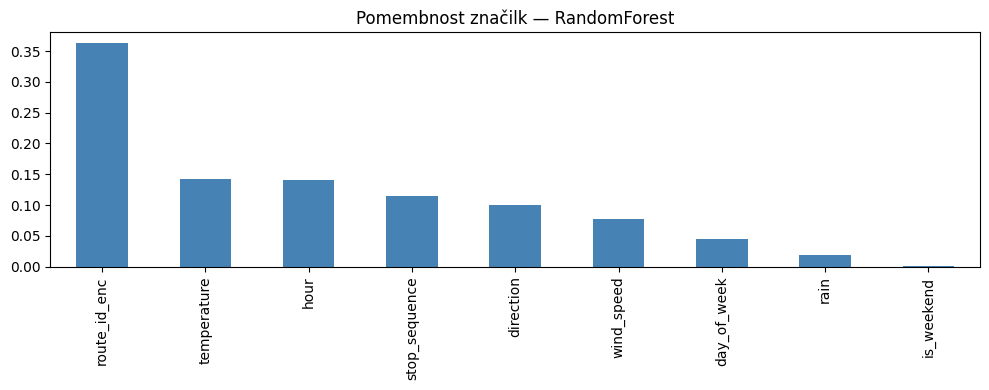

In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances)

importances.plot(kind='bar', color='steelblue', figsize=(10, 4))
plt.title('Pomembnost značilk — RandomForest')
plt.tight_layout()
plt.show()

In [ ]:
# testni primeri
# G1 (67), postaja 5, ponedeljek 8h, 18°C, brez dežja, smer 0
sample1 = pd.DataFrame([{
    'route_id_enc': 67, 'stop_sequence': 5, 'hour': 8,
    'day_of_week': 0, 'is_weekend': 0,
    'temperature': 18.0, 'rain': 0.0, 'wind_speed': 3.5, 'direction': 0
}])

# P16 Brezje (82) — najslabša linija, ponoči, slabo vreme, smer 1
sample2 = pd.DataFrame([{
    'route_id_enc': 82, 'stop_sequence': 20, 'hour': 22,
    'day_of_week': 4, 'is_weekend': 0,
    'temperature': 5.0, 'rain': 2.0, 'wind_speed': 6.0, 'direction': 1
}])

pred1 = best_rf.predict(sample1)[0]
pred2 = best_rf.predict(sample2)[0]

print(f"G1 - ponedeljek 8h, dobro vreme:     {pred1:.0f}s ({pred1/60:.1f} min)")
print(f"P16 Brezje - petek 22h, slabo vreme: {pred2:.0f}s ({pred2/60:.1f} min)")

G1 - ponedeljek 8h, dobro vreme:     106s (1.8 min)
P16 Brezje - petek 22h, slabo vreme: 413s (6.9 min)


## 12. Izvoz modela v ONNX

In [ ]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

out_dir = "../backend/src/main/resources/models"
os.makedirs(out_dir, exist_ok=True)

initial_type = [("float_input", FloatTensorType([None, len(FEATURES)]))]
onnx_model = convert_sklearn(best_rf, initial_types=initial_type)

output_path = f"{out_dir}/model_bus_delay.onnx"
with open(output_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"Shranjen model → {output_path}")
print(f"Vrstni red značilk: {FEATURES}")

Shranjen model → ../backend/src/main/resources/models/model_bus_delay.onnx
Vrstni red značilk: ['route_id_enc', 'stop_sequence', 'hour', 'day_of_week', 'is_weekend', 'temperature', 'rain', 'wind_speed', 'direction']
